In [6]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("../data/data_sales.csv")


# -------------------------------
# Basic Cleaning
# -------------------------------

# Remove duplicates
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

# Fix data types
df['Year'] = df['Year'].astype(int)
df['Engine_Size_L'] = df['Engine_Size_L'].astype(float)
df['Mileage_KM'] = df['Mileage_KM'].astype(float)
df['Price_USD'] = df['Price_USD'].astype(float)

# -------------------------------
# Feature Engineering
# -------------------------------

df['Car_Age'] = 2026 - df['Year']
df['Usage'] = df['Mileage_KM'] / (df['Car_Age'] + 1)

# -------------------------------
# Outlier Removal (IQR Method)
# -------------------------------

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply on important columns
df = remove_outliers(df, 'Price_USD')
df = remove_outliers(df, 'Mileage_KM')
df = remove_outliers(df, 'Engine_Size_L')

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (50000, 16)


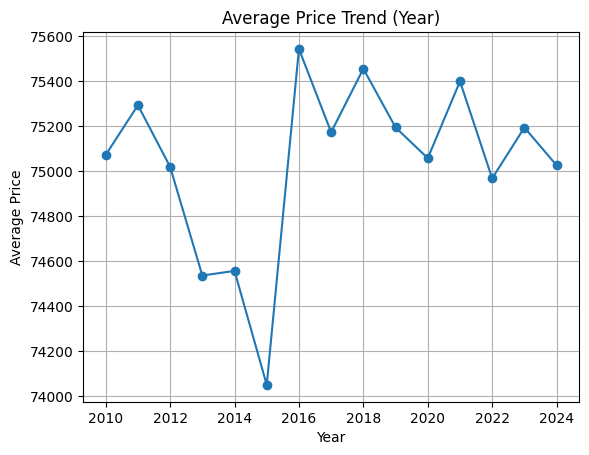

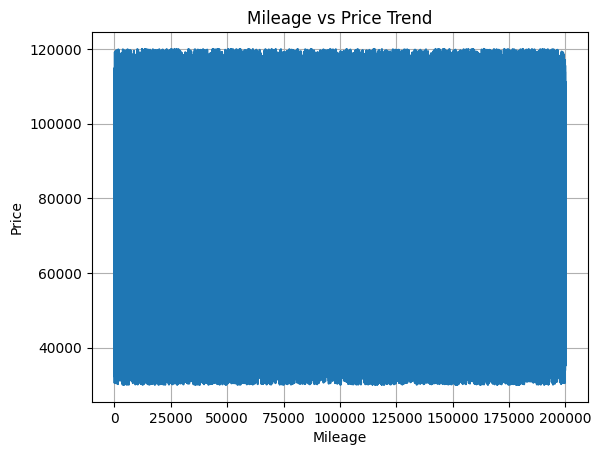

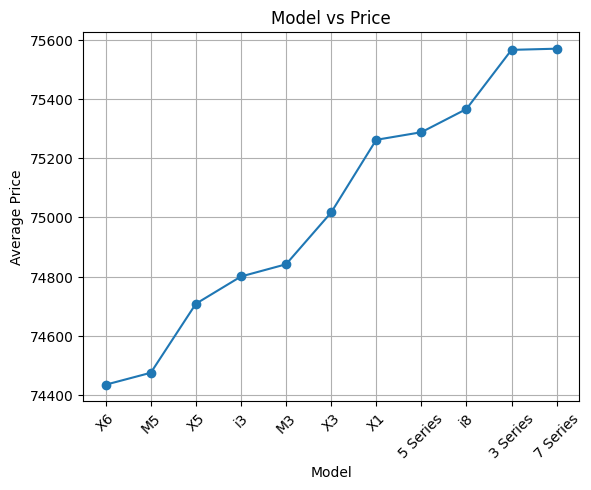

In [7]:
import matplotlib.pyplot as plt

# Step 1: Average price per year
year_price = df.groupby('Year')['Price_USD'].mean()

# Step 2: Sort by year (important)
year_price = year_price.sort_index()

# Step 3: Plot line
plt.plot(year_price.index, year_price.values, marker='o')

plt.title("Average Price Trend (Year)")
plt.xlabel("Year")
plt.ylabel("Average Price")

plt.grid(True)
plt.show()


# sort for smooth line
df_sorted = df.sort_values('Mileage_KM')

plt.plot(df_sorted['Mileage_KM'], df_sorted['Price_USD'])

plt.title("Mileage vs Price Trend")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.grid(True)
plt.show()


model_price = df.groupby('Model')['Price_USD'].mean()

model_price = model_price.sort_values()

plt.plot(model_price.index, model_price.values, marker='o')

plt.xticks(rotation=45)

plt.title("Model vs Price")
plt.xlabel("Model")
plt.ylabel("Average Price")

plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv('../data/data_sales.csv')

# ===============================
# CLEANING
# ===============================
df = df.drop_duplicates()
df = df.dropna()

# ===============================
# FEATURE ENGINEERING
# ===============================
df['Usage'] = df['Mileage_KM'] / (df['Car_Age'] + 1)
df['Age_sq'] = df['Car_Age'] ** 2
df['Power_Usage'] = df['Engine_Size_L'] / (df['Mileage_KM'] + 1)

# ===============================
# OUTLIER REMOVE
# ===============================
df = df[df['Price_Matched'] < df['Price_Matched'].quantile(0.95)]

# ===============================
# FEATURES
# ===============================
X = df[['Car_Age', 'Mileage_KM', 'Engine_Size_L',
        'Usage', 'Age_sq', 'Power_Usage',
        'Fuel_Type', 'Transmission', 'Color', 'Model']]

y = np.log1p(df['Price_Matched'])

X = X.copy()
X['Mileage_KM'] = np.log1p(X['Mileage_KM'])

# ===============================
# PREPROCESS
# ===============================
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ['Fuel_Type', 'Transmission', 'Color', 'Model']),
        ('num', 'passthrough',
         ['Car_Age', 'Mileage_KM', 'Engine_Size_L',
          'Usage', 'Age_sq', 'Power_Usage'])
    ]
)

# ===============================
# MODEL (RANDOM)
# ===============================
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', RandomForestRegressor(
        n_estimators=np.random.randint(300, 900),  # 🔥 random trees
        max_depth=None,
        min_samples_split=np.random.randint(2, 6),
        min_samples_leaf=np.random.randint(1, 3),
        max_features='sqrt'
    ))
])

# ===============================
# RANDOM SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2
    # ❌ no random_state → random split
)

# ===============================
# TRAIN
# ===============================
model.fit(X_train, y_train)

# ===============================
# PREDICT
# ===============================
y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# ===============================
# RESULT
# ===============================
print("R2 Score:", r2_score(y_test_actual, y_pred))
print("MAE:", mean_absolute_error(y_test_actual, y_pred))


In [ ]:
import joblib

joblib.dump(model, "car_price_model.pkl")